In [1]:
# Import packages
### YOUR CODE HERE ### 

# For data manipulation
import numpy as np
import pandas as pd

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For displaying all of the columns in dataframes
pd.set_option('display.max_columns', None)

# For data modeling
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# For metrics and helpful functions
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.tree import plot_tree

# For saving models
import pickle

In [7]:
# Importar la biblioteca necesaria
import pandas as pd

# Definir la ruta base
base_path = '/Users/ghost/Desktop/BIG DATA/Binary Prediction with a Rainfall Dataset'

# Definir las rutas completas de los archivos
train_path = f'{base_path}/train.csv'
test_path = f'{base_path}/test.csv'
submission_path = f'{base_path}/sample_submission.csv'

# Cargar los archivos CSV
train_data = pd.read_csv(train_path)         # Datos de entrenamiento
test_data = pd.read_csv(test_path)           # Datos de prueba
sample_submission = pd.read_csv(submission_path)  # Ejemplo de envío

# Ver las primeras filas de cada archivo para confirmar que se cargaron bien
print("Datos de entrenamiento:")
print(train_data.head())
print("\nDatos de prueba:")
print(test_data.head())
print("\nEjemplo de envío:")
print(sample_submission.head())

Datos de entrenamiento:
   id  day  pressure  maxtemp  temparature  mintemp  dewpoint  humidity  \
0   0    1    1017.4     21.2         20.6     19.9      19.4      87.0   
1   1    2    1019.5     16.2         16.9     15.8      15.4      95.0   
2   2    3    1024.1     19.4         16.1     14.6       9.3      75.0   
3   3    4    1013.4     18.1         17.8     16.9      16.8      95.0   
4   4    5    1021.8     21.3         18.4     15.2       9.6      52.0   

   cloud  sunshine  winddirection  windspeed  rainfall  
0   88.0       1.1           60.0       17.2         1  
1   91.0       0.0           50.0       21.9         1  
2   47.0       8.3           70.0       18.1         1  
3   95.0       0.0           60.0       35.6         1  
4   45.0       3.6           40.0       24.8         0  

Datos de prueba:
     id  day  pressure  maxtemp  temparature  mintemp  dewpoint  humidity  \
0  2190    1    1019.5     17.5         15.8     12.7      14.9      96.0   
1  2191    

In [8]:
# Tamaño de los datasets
print("Tamaño de train_data:", train_data.shape)
print("Tamaño de test_data:", test_data.shape)

# Columnas
print("\nColumnas de train_data:", train_data.columns.tolist())
print("Columnas de test_data:", test_data.columns.tolist())

# Valores faltantes
print("\nValores faltantes en train_data:\n", train_data.isnull().sum())
print("Valores faltantes en test_data:\n", test_data.isnull().sum())

# Distribución del target (rainfall)
print("\nDistribución de rainfall:\n", train_data['rainfall'].value_counts(normalize=True))

Tamaño de train_data: (2190, 13)
Tamaño de test_data: (730, 12)

Columnas de train_data: ['id', 'day', 'pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity', 'cloud', 'sunshine', 'winddirection', 'windspeed', 'rainfall']
Columnas de test_data: ['id', 'day', 'pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity', 'cloud', 'sunshine', 'winddirection', 'windspeed']

Valores faltantes en train_data:
 id               0
day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
sunshine         0
winddirection    0
windspeed        0
rainfall         0
dtype: int64
Valores faltantes en test_data:
 id               0
day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
sunshine         0
winddirection    1
windspeed        0
dtype: int64

Distribución de rainfall:
 rai

In [9]:
# Importar biblioteca
import pandas as pd

# Cargar los datos
base_path = '/Users/ghost/Desktop/BIG DATA/Binary Prediction with a Rainfall Dataset'
train_data = pd.read_csv(f'{base_path}/train.csv')
test_data = pd.read_csv(f'{base_path}/test.csv')

# 1. Mostrar las primeras filas
print("Primeras filas de train_data:")
print(train_data.head())
print("\nPrimeras filas de test_data:")
print(test_data.head())

# 2. Información básica del dataset
print("\nInformación de train_data:")
print(train_data.info())
print("\nInformación de test_data:")
print(test_data.info())

# 3. Estadísticas resumidas
print("\nEstadísticas de train_data:")
print(train_data.describe())
print("\nEstadísticas de test_data:")
print(test_data.describe())

# 4. Verificar valores faltantes
print("\nValores faltantes en train_data:")
print(train_data.isna().sum())
print("\nValores faltantes en test_data:")
print(test_data.isna().sum())

Primeras filas de train_data:
   id  day  pressure  maxtemp  temparature  mintemp  dewpoint  humidity  \
0   0    1    1017.4     21.2         20.6     19.9      19.4      87.0   
1   1    2    1019.5     16.2         16.9     15.8      15.4      95.0   
2   2    3    1024.1     19.4         16.1     14.6       9.3      75.0   
3   3    4    1013.4     18.1         17.8     16.9      16.8      95.0   
4   4    5    1021.8     21.3         18.4     15.2       9.6      52.0   

   cloud  sunshine  winddirection  windspeed  rainfall  
0   88.0       1.1           60.0       17.2         1  
1   91.0       0.0           50.0       21.9         1  
2   47.0       8.3           70.0       18.1         1  
3   95.0       0.0           60.0       35.6         1  
4   45.0       3.6           40.0       24.8         0  

Primeras filas de test_data:
     id  day  pressure  maxtemp  temparature  mintemp  dewpoint  humidity  \
0  2190    1    1019.5     17.5         15.8     12.7      14.9      9

In [10]:
# 1. Verificar duplicados en train_data
print("Duplicados en train_data (incluyendo id):", train_data.duplicated().sum())
print("Duplicados en train_data (excluyendo id):", train_data.drop(columns=['id']).duplicated().sum())

Duplicados en train_data (incluyendo id): 0
Duplicados en train_data (excluyendo id): 0


In [11]:
# 2. Verificar duplicados en test_data
print("\nDuplicados en test_data (incluyendo id):", test_data.duplicated().sum())
print("Duplicados en test_data (excluyendo id):", test_data.drop(columns=['id']).duplicated().sum())


Duplicados en test_data (incluyendo id): 0
Duplicados en test_data (excluyendo id): 0


<Figure size 1500x1000 with 0 Axes>

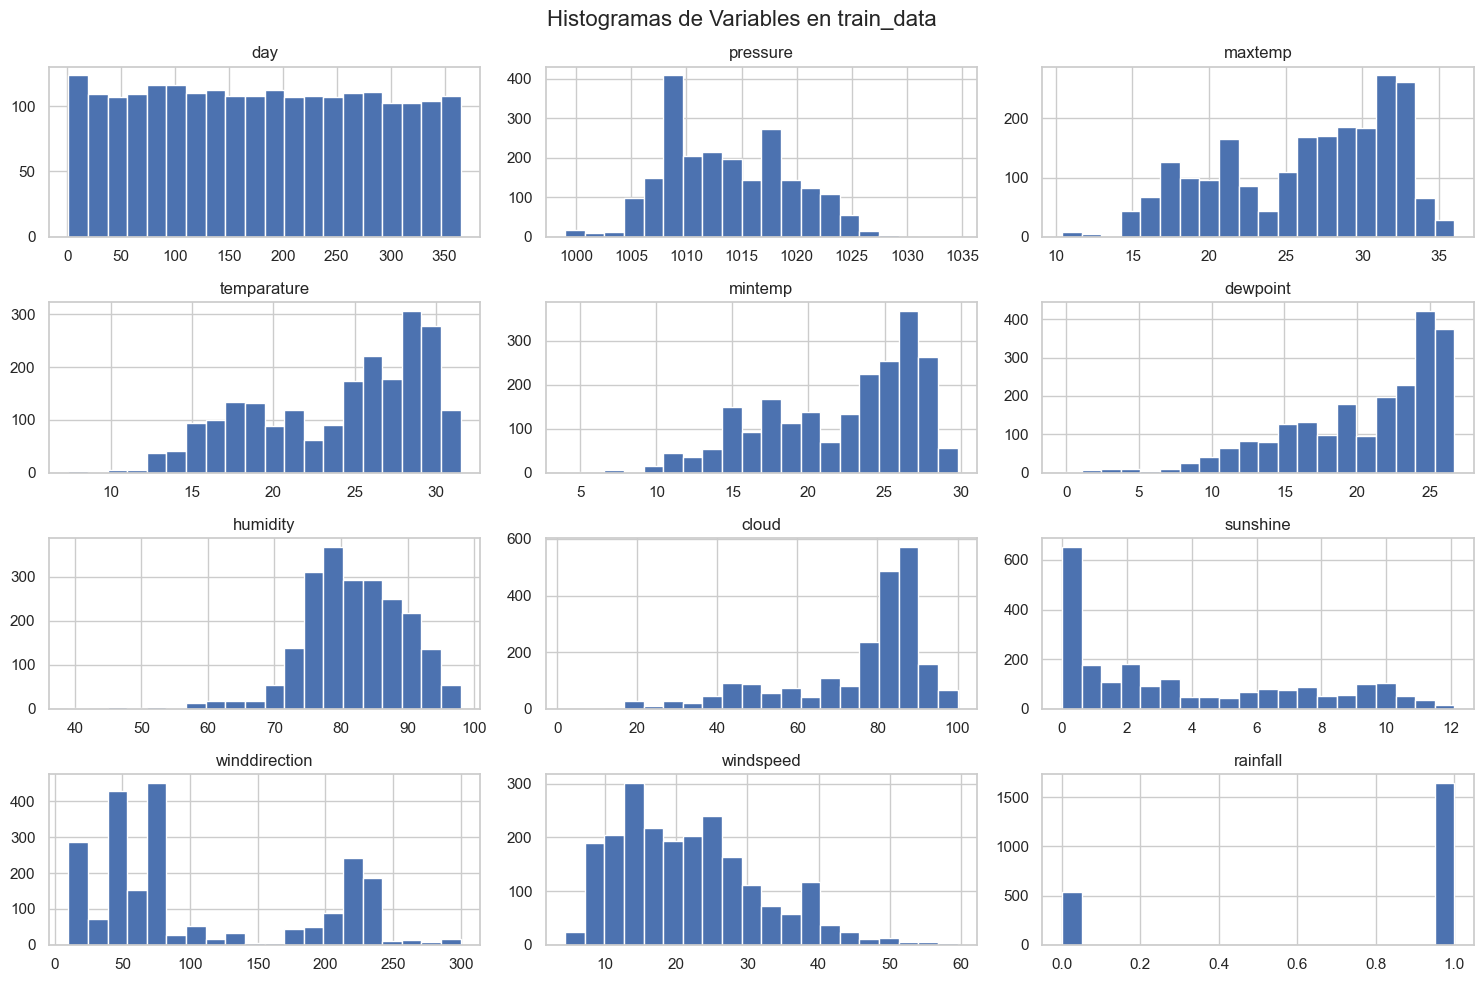

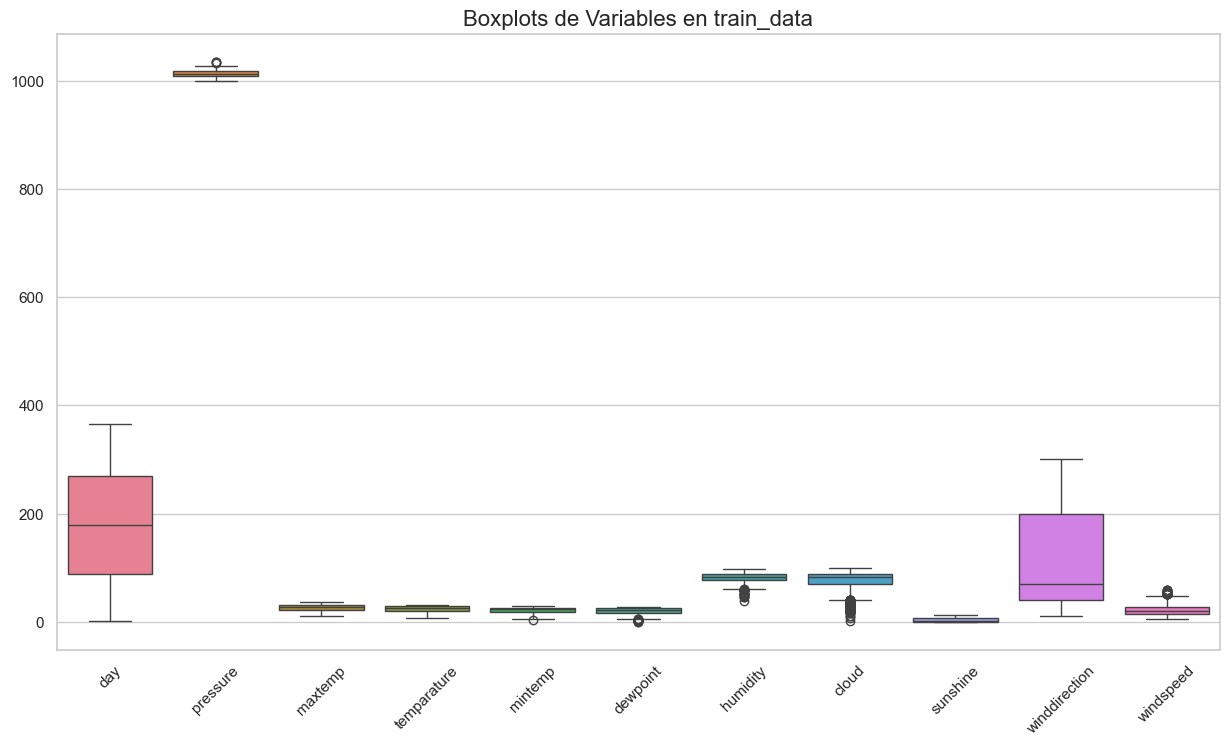

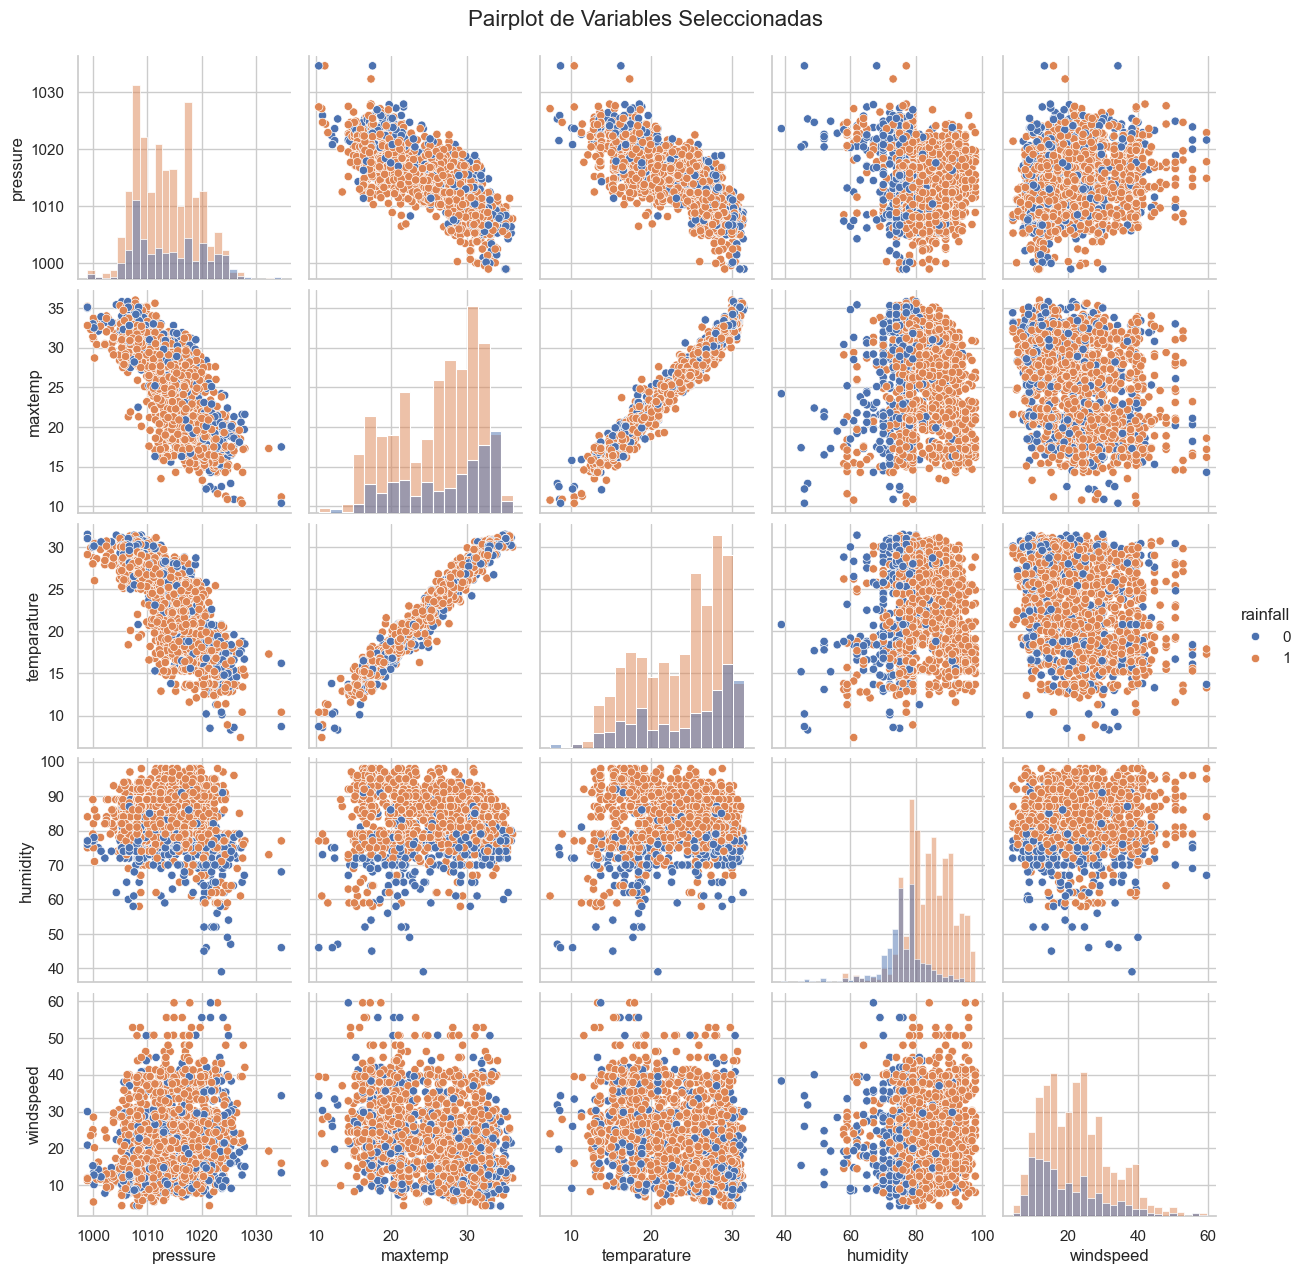

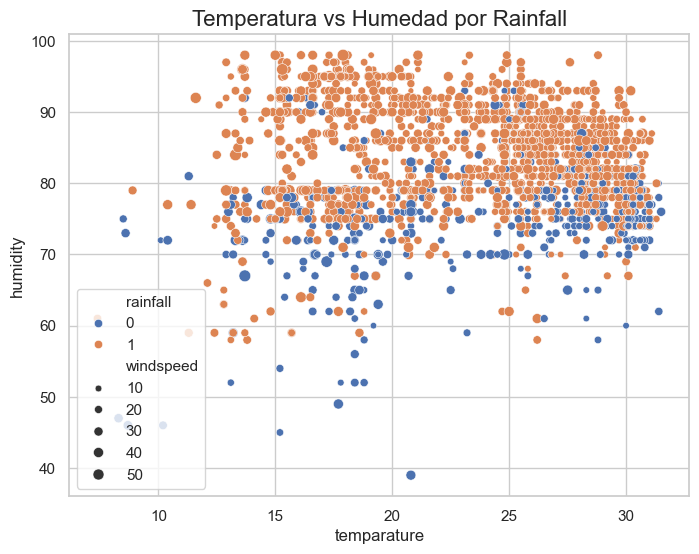


Valores atípicos por columna (Z-Score > 3):
day               0
pressure          4
maxtemp           0
temparature       1
mintemp           2
dewpoint         26
humidity         17
cloud            31
sunshine          0
winddirection     0
windspeed        15
dtype: int64

Valores atípicos por columna (IQR):
day                0
pressure           4
maxtemp            0
temparature        0
mintemp            1
dewpoint          26
humidity          28
cloud            129
sunshine           0
winddirection      0
windspeed         28
dtype: int64


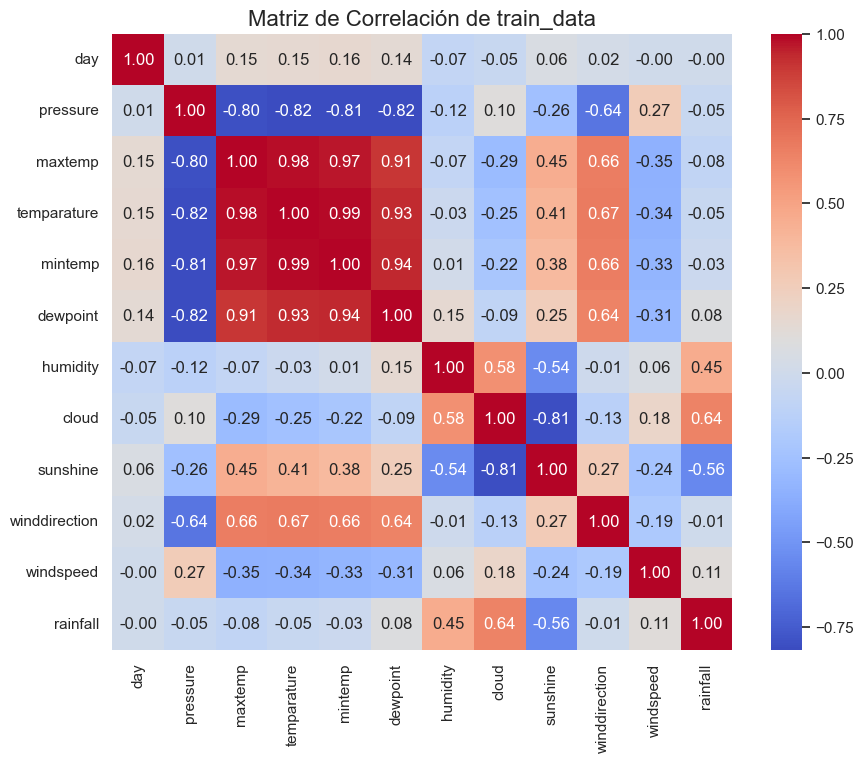

In [12]:
# Importar bibliotecas necesarias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Cargar los datos
base_path = '/Users/ghost/Desktop/BIG DATA/Binary Prediction with a Rainfall Dataset'
train_data = pd.read_csv(f'{base_path}/train.csv')
test_data = pd.read_csv(f'{base_path}/test.csv')

# 1. Visualización de datos

# Configurar estilo de Seaborn
sns.set(style="whitegrid")

# Histogramas de todas las columnas numéricas en train_data (excepto id)
plt.figure(figsize=(15, 10))
train_data.drop(columns=['id']).hist(bins=20, figsize=(15, 10))
plt.suptitle("Histogramas de Variables en train_data", fontsize=16)
plt.tight_layout()
plt.show()

# Boxplots para detectar valores atípicos visualmente
plt.figure(figsize=(15, 8))
sns.boxplot(data=train_data.drop(columns=['id', 'rainfall']))
plt.title("Boxplots de Variables en train_data", fontsize=16)
plt.xticks(rotation=45)
plt.show()

# Pairplot (relaciones entre variables, coloreado por rainfall)
sns.pairplot(train_data[['pressure', 'maxtemp', 'temparature', 'humidity', 'windspeed', 'rainfall']], 
             hue='rainfall', diag_kind='hist')
plt.suptitle("Pairplot de Variables Seleccionadas", y=1.02, fontsize=16)
plt.show()

# Gráfico adicional: Scatter plot de temparature vs humidity por rainfall
plt.figure(figsize=(8, 6))
sns.scatterplot(x='temparature', y='humidity', hue='rainfall', size='windspeed', data=train_data)
plt.title("Temperatura vs Humedad por Rainfall", fontsize=16)
plt.show()

# 2. Detección de valores atípicos

# Método Z-Score (valores con |z| > 3 se consideran atípicos)
z_scores = np.abs(stats.zscore(train_data.drop(columns=['id', 'rainfall'])))
outliers_z = (z_scores > 3).sum(axis=0)
print("\nValores atípicos por columna (Z-Score > 3):")
print(pd.Series(outliers_z, index=train_data.drop(columns=['id', 'rainfall']).columns))

# Método IQR (Interquartile Range)
def detect_outliers_iqr(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((df < lower_bound) | (df > upper_bound)).sum()
    return outliers

outliers_iqr = detect_outliers_iqr(train_data.drop(columns=['id', 'rainfall']))
print("\nValores atípicos por columna (IQR):")
print(outliers_iqr)

# 3. Matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(train_data.drop(columns=['id']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matriz de Correlación de train_data", fontsize=16)
plt.show()

In [13]:
# Importar bibliotecas
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Cargar los datos
base_path = '/Users/ghost/Desktop/BIG DATA/Binary Prediction with a Rainfall Dataset'
train_data = pd.read_csv(f'{base_path}/train.csv')
test_data = pd.read_csv(f'{base_path}/test.csv')
sample_submission = pd.read_csv(f'{base_path}/sample_submission.csv')

# Rellenar el valor faltante en test_data
winddirection_median = train_data['winddirection'].median()
test_data['winddirection'] = test_data['winddirection'].fillna(winddirection_median)
print("Valor faltante en winddirection rellenado con:", winddirection_median)

# Preparar los datos (sin eliminar outliers)
X_train = train_data.drop(columns=['id', 'rainfall'])
y_train = train_data['rainfall']
X_test = test_data.drop(columns=['id'])

# Dividir train_data en entrenamiento y validación
X_train_split, X_val, y_train_split, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Entrenar modelo
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_split, y_train_split)

# Evaluar
y_val_pred = model.predict_proba(X_val)[:, 1]
roc_auc = roc_auc_score(y_val, y_val_pred)
print("ROC AUC en validación:", roc_auc)

# Generar predicciones
y_test_pred = model.predict_proba(X_test)[:, 1]

# Crear submission
submission = sample_submission.copy()
submission['rainfall'] = y_test_pred
print("Submission:\n", submission.head())
submission.to_csv(f'{base_path}/submission.csv', index=False)
print("Archivo submission.csv guardado!")

Valor faltante en winddirection rellenado con: 70.0
ROC AUC en validación: 0.8572613998577487
Submission:
      id  rainfall
0  2190      0.99
1  2191      0.99
2  2192      0.83
3  2193      0.18
4  2194      0.02
Archivo submission.csv guardado!


In [14]:
model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)

In [15]:
from xgboost import XGBClassifier
model = XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='auc', random_state=42)

In [16]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')
print("ROC AUC promedio (5-fold):", scores.mean())

/Users/ghost/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [14:12:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/ghost/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [14:12:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/ghost/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [14:12:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/ghost/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [14:12:38] WARNING: /Users/runner/work/xgboost/xgboost

ROC AUC promedio (5-fold): 0.8706172839506173


In [17]:
# Importar bibliotecas
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score

# Cargar los datos
base_path = '/Users/ghost/Desktop/BIG DATA/Binary Prediction with a Rainfall Dataset'
train_data = pd.read_csv(f'{base_path}/train.csv')
test_data = pd.read_csv(f'{base_path}/test.csv')
sample_submission = pd.read_csv(f'{base_path}/sample_submission.csv')

# Rellenar el valor faltante en test_data
winddirection_median = train_data['winddirection'].median()
test_data['winddirection'] = test_data['winddirection'].fillna(winddirection_median)
print("Valor faltante en winddirection rellenado con:", winddirection_median)

# Preparar los datos
X_train = train_data.drop(columns=['id', 'rainfall'])
y_train = train_data['rainfall']
X_test = test_data.drop(columns=['id'])

# Validación cruzada (ya lo hiciste, solo para confirmar)
model = XGBClassifier(n_estimators=100, eval_metric='auc', random_state=42)
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')
print("ROC AUC promedio (5-fold):", scores.mean())

# Entrenar el modelo en todo train_data
model.fit(X_train, y_train)

# Generar predicciones para test_data
y_test_pred = model.predict_proba(X_test)[:, 1]

# Crear el archivo de submission
submission = sample_submission.copy()
submission['rainfall'] = y_test_pred
print("Submission:\n", submission.head())

# Guardar el archivo
submission.to_csv(f'{base_path}/submission_xgboost.csv', index=False)
print("Archivo submission_xgboost.csv guardado!")

Valor faltante en winddirection rellenado con: 70.0
ROC AUC promedio (5-fold): 0.8706172839506173
Submission:
      id  rainfall
0  2190  0.999636
1  2191  0.999466
2  2192  0.984341
3  2193  0.066674
4  2194  0.018743
Archivo submission_xgboost.csv guardado!


In [18]:
# Añadir features a train_data y test_data
train_data['temp_range'] = train_data['maxtemp'] - train_data['mintemp']
train_data['humidity_cloud_interaction'] = train_data['humidity'] * train_data['cloud']
train_data['solar_effect'] = train_data['sunshine'] * (1 - train_data['cloud'])

test_data['temp_range'] = test_data['maxtemp'] - test_data['mintemp']
test_data['humidity_cloud_interaction'] = test_data['humidity'] * test_data['cloud']
test_data['solar_effect'] = test_data['sunshine'] * (1 - test_data['cloud'])

# Preparar datos con nuevas features
X_train = train_data.drop(columns=['id', 'rainfall'])
y_train = train_data['rainfall']
X_test = test_data.drop(columns=['id'])

# Modelo base (puedes usar el optimizado de arriba)
model = XGBClassifier(n_estimators=100, eval_metric='auc', random_state=42)
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')
print("ROC AUC promedio (5-fold) con features:", scores.mean())

# Entrenar y predecir
model.fit(X_train, y_train)
y_test_pred = model.predict_proba(X_test)[:, 1]

# Crear submission
submission = sample_submission.copy()
submission['rainfall'] = y_test_pred
submission.to_csv(f'{base_path}/submission_xgboost_features.csv', index=False)
print("Submission guardado como submission_xgboost_features.csv")

ROC AUC promedio (5-fold) con features: 0.8673737373737372
Submission guardado como submission_xgboost_features.csv


In [19]:
# Añadir features a train_data y test_data
train_data['temp_range'] = train_data['maxtemp'] - train_data['mintemp']
train_data['humidity_cloud_interaction'] = train_data['humidity'] * train_data['cloud']
train_data['solar_effect'] = train_data['sunshine'] * (1 - train_data['cloud'])

test_data['temp_range'] = test_data['maxtemp'] - test_data['mintemp']
test_data['humidity_cloud_interaction'] = test_data['humidity'] * test_data['cloud']
test_data['solar_effect'] = test_data['sunshine'] * (1 - test_data['cloud'])

# Preparar datos con nuevas features
X_train = train_data.drop(columns=['id', 'rainfall'])
y_train = train_data['rainfall']
X_test = test_data.drop(columns=['id'])

# Modelo base (puedes usar el optimizado de arriba)
model = XGBClassifier(n_estimators=100, eval_metric='auc', random_state=42)
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')
print("ROC AUC promedio (5-fold) con features:", scores.mean())

# Entrenar y predecir
model.fit(X_train, y_train)
y_test_pred = model.predict_proba(X_test)[:, 1]

# Crear submission
submission = sample_submission.copy()
submission['rainfall'] = y_test_pred
submission.to_csv(f'{base_path}/submission_xgboost_features.csv', index=False)
print("Submission guardado como submission_xgboost_features.csv")

ROC AUC promedio (5-fold) con features: 0.8673737373737372
Submission guardado como submission_xgboost_features.csv


In [20]:
from sklearn.ensemble import RandomForestClassifier

# Modelo 1: XGBoost
xgb_model = XGBClassifier(n_estimators=100, eval_metric='auc', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict_proba(X_test)[:, 1]

# Modelo 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict_proba(X_test)[:, 1]

# Promedio de predicciones (blending simple)
blend_preds = 0.6 * xgb_preds + 0.4 * rf_preds  # Ajusta los pesos si quieres

# Crear submission
submission = sample_submission.copy()
submission['rainfall'] = blend_preds
submission.to_csv(f'{base_path}/submission_blend.csv', index=False)
print("Submission guardado como submission_blend.csv")

Submission guardado como submission_blend.csv


In [21]:
from sklearn.calibration import CalibratedClassifierCV

# Modelo base
base_model = XGBClassifier(n_estimators=100, eval_metric='auc', random_state=42)
calibrated_model = CalibratedClassifierCV(base_model, method='sigmoid', cv=5)

# Entrenar y predecir
calibrated_model.fit(X_train, y_train)
y_test_pred = calibrated_model.predict_proba(X_test)[:, 1]

# Crear submission
submission = sample_submission.copy()
submission['rainfall'] = y_test_pred
submission.to_csv(f'{base_path}/submission_calibrated.csv', index=False)
print("Submission guardado como submission_calibrated.csv")

Submission guardado como submission_calibrated.csv


In [22]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import cross_val_score

# Cargar datos
base_path = '/Users/ghost/Desktop/BIG DATA/Binary Prediction with a Rainfall Dataset'
train_data = pd.read_csv(f'{base_path}/train.csv')
test_data = pd.read_csv(f'{base_path}/test.csv')
sample_submission = pd.read_csv(f'{base_path}/sample_submission.csv')

# Rellenar valor faltante en winddirection
test_data['winddirection'] = test_data['winddirection'].fillna(train_data['winddirection'].median())

# Preparar datos
X_train = train_data.drop(columns=['id', 'rainfall'])
y_train = train_data['rainfall']
X_test = test_data.drop(columns=['id'])

# Definir modelo base (XGBoost)
base_model = XGBClassifier(n_estimators=100, eval_metric='auc', random_state=42)

# Calibrar el modelo
calibrated_model = CalibratedClassifierCV(base_model, method='sigmoid', cv=5)
calibrated_model.fit(X_train, y_train)

# Validación cruzada para verificar rendimiento
scores = cross_val_score(calibrated_model, X_train, y_train, cv=5, scoring='roc_auc')
print("ROC AUC promedio (5-fold) con calibración:", scores.mean())

ROC AUC promedio (5-fold) con calibración: 0.8752637485970819


In [23]:
# Generar predicciones de probabilidad para test_data
y_test_pred = calibrated_model.predict_proba(X_test)[:, 1]

# Mostrar las primeras predicciones para verificar
print("Primeras 5 predicciones:\n", y_test_pred[:5])

Primeras 5 predicciones:
 [0.91215736 0.91186374 0.90882066 0.25897669 0.17852751]


In [25]:
# Crear el archivo de submission con las predicciones
submission = sample_submission.copy()
submission['rainfall'] = y_test_pred  # y_test_pred es el array que contiene [0.91215736, ...]

# Mostrar las primeras filas
print("Primeras filas de submission:\n", submission.head())

# Guardar el archivo
submission.to_csv(f'{base_path}/submission_calibrated.csv', index=False)
print("Archivo submission_calibrated.csv guardado!")

Primeras filas de submission:
      id  rainfall
0  2190  0.912157
1  2191  0.911864
2  2192  0.908821
3  2193  0.258977
4  2194  0.178528
Archivo submission_calibrated.csv guardado!


In [26]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import cross_val_score

# Cargar datos
base_path = '/Users/ghost/Desktop/BIG DATA/Binary Prediction with a Rainfall Dataset'
train_data = pd.read_csv(f'{base_path}/train.csv')
test_data = pd.read_csv(f'{base_path}/test.csv')
sample_submission = pd.read_csv(f'{base_path}/sample_submission.csv')

# Rellenar valor faltante
test_data['winddirection'] = test_data['winddirection'].fillna(train_data['winddirection'].median())

# Preparar datos
X_train = train_data.drop(columns=['id', 'rainfall'])
y_train = train_data['rainfall']
X_test = test_data.drop(columns=['id'])

# Modelo base optimizado
base_model = XGBClassifier(
    n_estimators=200,        # Más árboles
    max_depth=4,             # Limitar profundidad para evitar sobreajuste
    learning_rate=0.05,      # Tasa baja para mejor convergencia
    subsample=0.8,           # Regularización
    colsample_bytree=0.8,    # Regularización
    eval_metric='auc',
    random_state=42
)

# Calibrar
calibrated_model = CalibratedClassifierCV(base_model, method='sigmoid', cv=5)

# Validación cruzada
scores = cross_val_score(calibrated_model, X_train, y_train, cv=5, scoring='roc_auc')
print("ROC AUC promedio (5-fold) con calibración y optimización:", scores.mean())

# Entrenar y predecir
calibrated_model.fit(X_train, y_train)
y_test_pred = calibrated_model.predict_proba(X_test)[:, 1]

# Crear submission
submission = sample_submission.copy()
submission['rainfall'] = y_test_pred
print("Primeras filas de submission:\n", submission.head())
submission.to_csv(f'{base_path}/submission_calibrated_opt.csv', index=False)
print("Archivo submission_calibrated_opt.csv guardado!")

ROC AUC promedio (5-fold) con calibración y optimización: 0.8865488215488216
Primeras filas de submission:
      id  rainfall
0  2190  0.938088
1  2191  0.937996
2  2192  0.926879
3  2193  0.140759
4  2194  0.112682
Archivo submission_calibrated_opt.csv guardado!


In [27]:
# Añadir features
train_data['temp_range'] = train_data['maxtemp'] - train_data['mintemp']
train_data['humidity_cloud'] = train_data['humidity'] * train_data['cloud']
test_data['temp_range'] = test_data['maxtemp'] - test_data['mintemp']
test_data['humidity_cloud'] = test_data['humidity'] * test_data['cloud']

# Preparar datos
X_train = train_data.drop(columns=['id', 'rainfall'])
y_train = train_data['rainfall']
X_test = test_data.drop(columns=['id'])

# Modelo base y calibración
base_model = XGBClassifier(n_estimators=100, eval_metric='auc', random_state=42)
calibrated_model = CalibratedClassifierCV(base_model, method='sigmoid', cv=5)

# Validación cruzada
scores = cross_val_score(calibrated_model, X_train, y_train, cv=5, scoring='roc_auc')
print("ROC AUC promedio (5-fold) con features:", scores.mean())

# Entrenar y predecir
calibrated_model.fit(X_train, y_train)
y_test_pred = calibrated_model.predict_proba(X_test)[:, 1]

# Crear submission
submission = sample_submission.copy()
submission['rainfall'] = y_test_pred
submission.to_csv(f'{base_path}/submission_calibrated_features.csv', index=False)
print("Archivo submission_calibrated_features.csv guardado!")

ROC AUC promedio (5-fold) con features: 0.8724579124579124
Archivo submission_calibrated_features.csv guardado!


In [28]:
from sklearn.ensemble import RandomForestClassifier

# Modelo 1: XGBoost calibrado
base_model = XGBClassifier(n_estimators=100, eval_metric='auc', random_state=42)
calibrated_model = CalibratedClassifierCV(base_model, method='sigmoid', cv=5)
calibrated_model.fit(X_train, y_train)
calibrated_preds = calibrated_model.predict_proba(X_test)[:, 1]

# Modelo 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict_proba(X_test)[:, 1]

# Blending (promedio ponderado)
blend_preds = 0.7 * calibrated_preds + 0.3 * rf_preds  # Ajusta los pesos si quieres

# Crear submission
submission = sample_submission.copy()
submission['rainfall'] = blend_preds
submission.to_csv(f'{base_path}/submission_blend.csv', index=False)
print("Archivo submission_blend.csv guardado!")

Archivo submission_blend.csv guardado!


In [29]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import cross_val_score

# Cargar datos
base_path = '/Users/ghost/Desktop/BIG DATA/Binary Prediction with a Rainfall Dataset'
train_data = pd.read_csv(f'{base_path}/train.csv')
test_data = pd.read_csv(f'{base_path}/test.csv')
sample_submission = pd.read_csv(f'{base_path}/sample_submission.csv')

# Rellenar valor faltante
test_data['winddirection'] = test_data['winddirection'].fillna(train_data['winddirection'].median())

# Preparar datos
X_train = train_data.drop(columns=['id', 'rainfall'])
y_train = train_data['rainfall']
X_test = test_data.drop(columns=['id'])

# Modelo 1: XGBoost calibrado
base_model = XGBClassifier(n_estimators=100, eval_metric='auc', random_state=42)
calibrated_model = CalibratedClassifierCV(base_model, method='sigmoid', cv=5)
calibrated_model.fit(X_train, y_train)
calibrated_preds = calibrated_model.predict_proba(X_test)[:, 1]

# Validación cruzada para XGBoost calibrado (opcional, para referencia)
scores_calibrated = cross_val_score(calibrated_model, X_train, y_train, cv=5, scoring='roc_auc')
print("ROC AUC promedio (5-fold) XGBoost calibrado:", scores_calibrated.mean())

# Modelo 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict_proba(X_test)[:, 1]

# Validación cruzada para Random Forest (opcional, para referencia)
scores_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='roc_auc')
print("ROC AUC promedio (5-fold) Random Forest:", scores_rf.mean())

# Blending: Combinar predicciones (70% XGBoost calibrado + 30% Random Forest)
blend_preds = 0.7 * calibrated_preds + 0.3 * rf_preds

# Mostrar las primeras predicciones combinadas
print("Primeras 5 predicciones combinadas:\n", blend_preds[:5])

# Crear submission
submission = sample_submission.copy()
submission['rainfall'] = blend_preds
print("Primeras filas de submission:\n", submission.head())
submission.to_csv(f'{base_path}/submission_blend.csv', index=False)
print("Archivo submission_blend.csv guardado!")

ROC AUC promedio (5-fold) XGBoost calibrado: 0.8752637485970819
ROC AUC promedio (5-fold) Random Forest: 0.8819584736251403
Primeras 5 predicciones combinadas:
 [0.93551015 0.93830462 0.90617447 0.23228369 0.14896926]
Primeras filas de submission:
      id  rainfall
0  2190  0.935510
1  2191  0.938305
2  2192  0.906174
3  2193  0.232284
4  2194  0.148969
Archivo submission_blend.csv guardado!


In [30]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV

# Cargar datos
base_path = '/Users/ghost/Desktop/BIG DATA/Binary Prediction with a Rainfall Dataset'
train_data = pd.read_csv(f'{base_path}/train.csv')
test_data = pd.read_csv(f'{base_path}/test.csv')
sample_submission = pd.read_csv(f'{base_path}/sample_submission.csv')

# Rellenar valor faltante
test_data['winddirection'] = test_data['winddirection'].fillna(train_data['winddirection'].median())

# Preparar datos
X_train = train_data.drop(columns=['id', 'rainfall'])
y_train = train_data['rainfall']
X_test = test_data.drop(columns=['id'])

# Modelo 1: XGBoost calibrado
base_model = XGBClassifier(n_estimators=100, eval_metric='auc', random_state=42)
calibrated_model = CalibratedClassifierCV(base_model, method='sigmoid', cv=5)
calibrated_model.fit(X_train, y_train)
calibrated_preds = calibrated_model.predict_proba(X_test)[:, 1]

# Modelo 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict_proba(X_test)[:, 1]

# Blending (70% XGBoost + 30% RF)
blend_preds = 0.7 * calibrated_preds + 0.3 * rf_preds

# Crear submission
submission = sample_submission.copy()
submission['rainfall'] = blend_preds
submission.to_csv(f'{base_path}/submission_blend.csv', index=False)
print("Archivo submission_blend.csv guardado!")

Archivo submission_blend.csv guardado!


In [31]:
from lightgbm import LGBMClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import cross_val_score

# Modelo LightGBM optimizado
lgbm_model = LGBMClassifier(
    n_estimators=500,        # Más árboles
    max_depth=6,             # Profundidad moderada
    learning_rate=0.03,      # Tasa baja
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Calibrar
calibrated_lgbm = CalibratedClassifierCV(lgbm_model, method='sigmoid', cv=5)

# Validación cruzada
scores = cross_val_score(calibrated_lgbm, X_train, y_train, cv=5, scoring='roc_auc')
print("ROC AUC promedio (5-fold) LightGBM calibrado:", scores.mean())

# Entrenar y predecir
calibrated_lgbm.fit(X_train, y_train)
lgbm_preds = calibrated_lgbm.predict_proba(X_test)[:, 1]

# Crear submission
submission = sample_submission.copy()
submission['rainfall'] = lgbm_preds
submission.to_csv(f'{base_path}/submission_lgbm.csv', index=False)
print("Archivo submission_lgbm.csv guardado!")

[LightGBM] [Info] Number of positive: 1056, number of negative: 345
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000334 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1476
[LightGBM] [Info] Number of data points in the train set: 1401, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.753747 -> initscore=1.118699
[LightGBM] [Info] Start training from score 1.118699
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

In [32]:
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import cross_val_score

# Cargar datos
base_path = '/Users/ghost/Desktop/BIG DATA/Binary Prediction with a Rainfall Dataset'
train_data = pd.read_csv(f'{base_path}/train.csv')
test_data = pd.read_csv(f'{base_path}/test.csv')
sample_submission = pd.read_csv(f'{base_path}/sample_submission.csv')

# Rellenar valor faltante
test_data['winddirection'] = test_data['winddirection'].fillna(train_data['winddirection'].median())

# Preparar datos
X_train = train_data.drop(columns=['id', 'rainfall'])
y_train = train_data['rainfall']
X_test = test_data.drop(columns=['id'])

# Modelo LightGBM optimizado
lgbm_model = LGBMClassifier(
    n_estimators=500,        # Más árboles
    max_depth=6,             # Profundidad moderada
    learning_rate=0.03,      # Tasa baja
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Calibrar
calibrated_lgbm = CalibratedClassifierCV(lgbm_model, method='sigmoid', cv=5)

# Validación cruzada
scores = cross_val_score(calibrated_lgbm, X_train, y_train, cv=5, scoring='roc_auc')
print("ROC AUC promedio (5-fold) LightGBM calibrado:", scores.mean())

# Entrenar y predecir
calibrated_lgbm.fit(X_train, y_train)
lgbm_preds = calibrated_lgbm.predict_proba(X_test)[:, 1]

# Mostrar primeras predicciones
print("Primeras 5 predicciones:\n", lgbm_preds[:5])

# Crear submission
submission = sample_submission.copy()
submission['rainfall'] = lgbm_preds
print("Primeras filas de submission:\n", submission.head())
submission.to_csv(f'{base_path}/submission_lgbm.csv', index=False)
print("Archivo submission_lgbm.csv guardado!")

[LightGBM] [Info] Number of positive: 1056, number of negative: 345
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.044297 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1476
[LightGBM] [Info] Number of data points in the train set: 1401, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.753747 -> initscore=1.118699
[LightGBM] [Info] Start training from score 1.118699
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

In [34]:
import pandas as pd
from lightgbm import LGBMClassifier

# Definir la ruta base
base_path = '/Users/ghost/Desktop/BIG DATA/Binary Prediction with a Rainfall Dataset'

# Cargar datos con manejo de errores
try:
    train_data = pd.read_csv(f'{base_path}/train.csv')
    test_data = pd.read_csv(f'{base_path}/test.csv')
    sample_submission = pd.read_csv(f'{base_path}/sample_submission.csv')
    print("Datos cargados correctamente.")
except FileNotFoundError as e:
    print(f"Error: No se encontraron los archivos. Verifica la ruta: {base_path}")
    raise e
except Exception as e:
    print(f"Error al cargar los datos: {e}")
    raise e

# Rellenar valor faltante en winddirection
test_data['winddirection'] = test_data['winddirection'].fillna(train_data['winddirection'].median())
print("Valor faltante en winddirection rellenado.")

# Preparar datos
X_train = train_data.drop(columns=['id', 'rainfall'])
y_train = train_data['rainfall']
X_test = test_data.drop(columns=['id'])

# Verificar dimensiones y NaN
print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("NaN en X_train:", X_train.isna().sum().sum())
print("NaN en X_test:", X_test.isna().sum().sum())

# Modelo LightGBM básico
lgbm_model = LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1  # Silenciar advertencias excesivas
)

# Entrenar el modelo
try:
    print("Entrenando el modelo LightGBM...")
    lgbm_model.fit(X_train, y_train)
    print("Modelo entrenado correctamente.")
except Exception as e:
    print(f"Error al entrenar el modelo: {e}")
    raise e

# Generar predicciones
try:
    lgbm_preds = lgbm_model.predict_proba(X_test)[:, 1]
    print("Primeras 5 predicciones:\n", lgbm_preds[:5])
except Exception as e:
    print(f"Error al generar predicciones: {e}")
    raise e

# Crear submission
submission = sample_submission.copy()
submission['rainfall'] = lgbm_preds
print("Primeras filas de submission:\n", submission.head())

# Guardar archivo
try:
    submission.to_csv(f'{base_path}/submission_lgbm_simple.csv', index=False)
    print("Archivo submission_lgbm_simple.csv guardado!")
except Exception as e:
    print(f"Error al guardar el archivo: {e}")
    raise e

Datos cargados correctamente.
Valor faltante en winddirection rellenado.
Dimensiones de X_train: (2190, 11)
Dimensiones de y_train: (2190,)
Dimensiones de X_test: (730, 11)
NaN en X_train: 0
NaN en X_test: 0
Entrenando el modelo LightGBM...
Modelo entrenado correctamente.
Primeras 5 predicciones:
 [0.99948538 0.99937893 0.99068097 0.19071849 0.01344998]
Primeras filas de submission:
      id  rainfall
0  2190  0.999485
1  2191  0.999379
2  2192  0.990681
3  2193  0.190718
4  2194  0.013450
Archivo submission_lgbm_simple.csv guardado!
